In [1]:
from bidr_relight.main import relight_content_image
from bidr_relight.plot import plot_bin_masks
import numpy as np
import torch

from skimage.io import imread, imsave
import matplotlib.pyplot as plt
import os

%load_ext autoreload
%autoreload 2

In [3]:
# Aux
CONTENT = 0
STYLE = 1


def cosine_similarity(v1, v2):
    """
    (N, 3)
    """
    # Normalize each vector
    v1_norm = v1 / np.linalg.norm(v1, axis=1, keepdims=True)
    v2_norm = v2 / np.linalg.norm(v2, axis=1, keepdims=True)

    # Dot product along last dimension
    cosines = np.sum(v1_norm * v2_norm, axis=1)
    return cosines


INFO: Initializing ResNet50UNet | in_channels=3, out_channels=3, pretrained=True, checkpoint=../weights/unet.pth, se_block=True
INFO: Loading ResNet50 weights from checkpoint: ../weights/unet.pth


INFO: ResNet50UNet Parameter Summary (Top-Level Modules):
INFO: --------------------------------------------------------------------------------
INFO: in_conv                   | Total: 9536                 | Trainable: 9,536
INFO: maxpool                   | Total: 0                    | Trainable: 0
INFO: enc1                      | Total: 215808               | Trainable: 215,808
INFO: enc2                      | Total: 1219584              | Trainable: 1,219,584
INFO: enc3                      | Total: 7098368              | Trainable: 7,098,368
INFO: enc4                      | Total: 14964736             | Trainable: 14,964,736
INFO: up4                       | Total: 16551456             | Trainable: 16,551,456
INFO: up3                       | Total: 2959120              | Trainable: 2,959,120
INFO: up2                       | Total: 740232               | Trainable: 740,232
INFO: up1                       | Total: 148420               | Trainable: 148,420
INFO: up0            

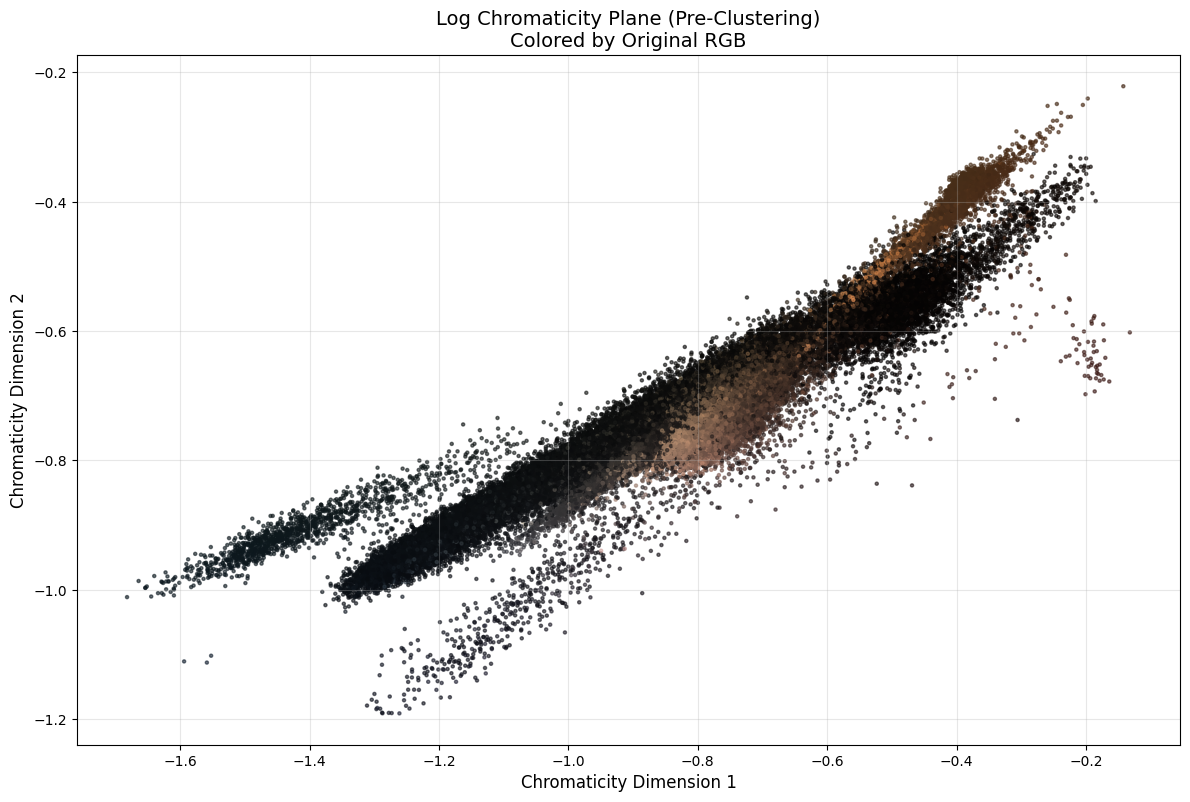

INFO: Greedy clustering: 13 clusters with radius=0.2


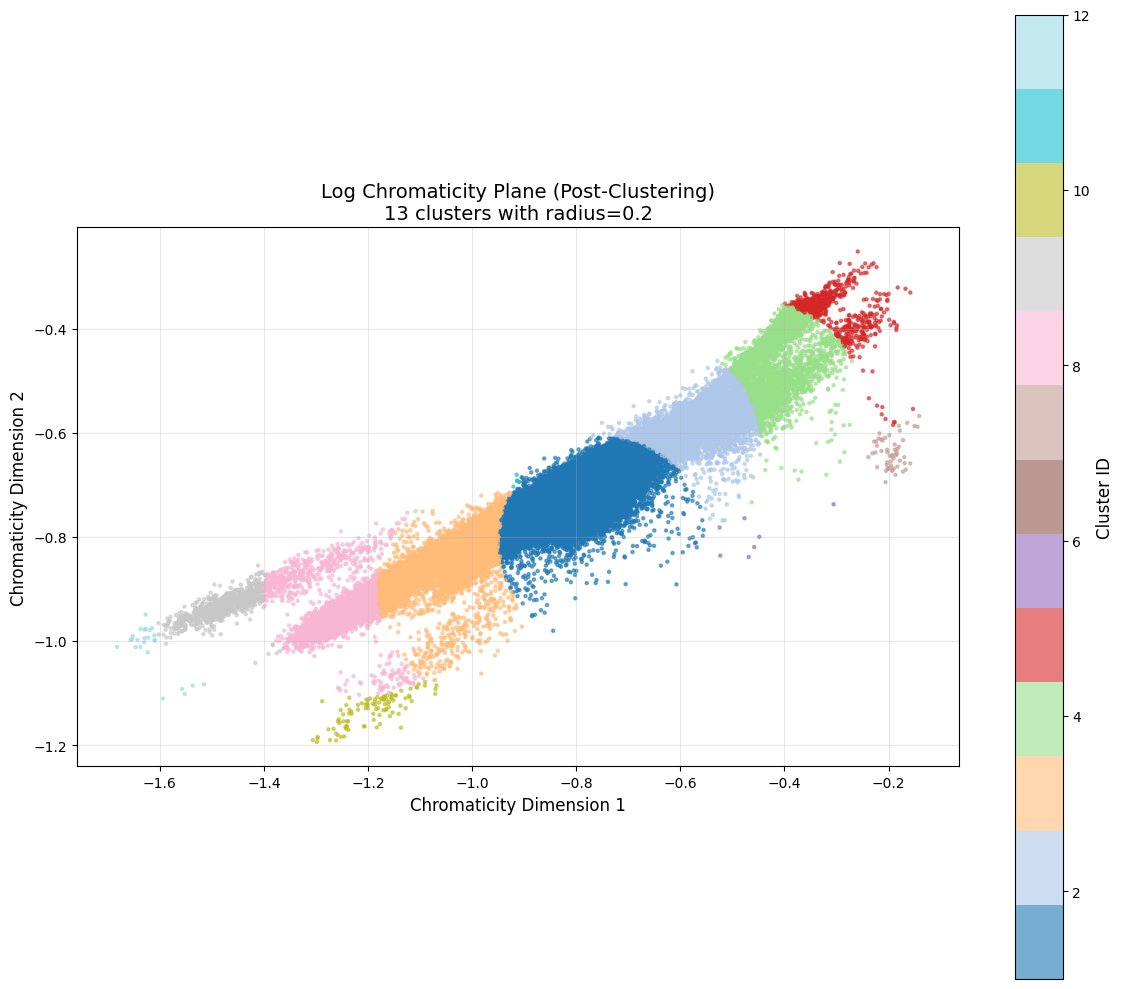

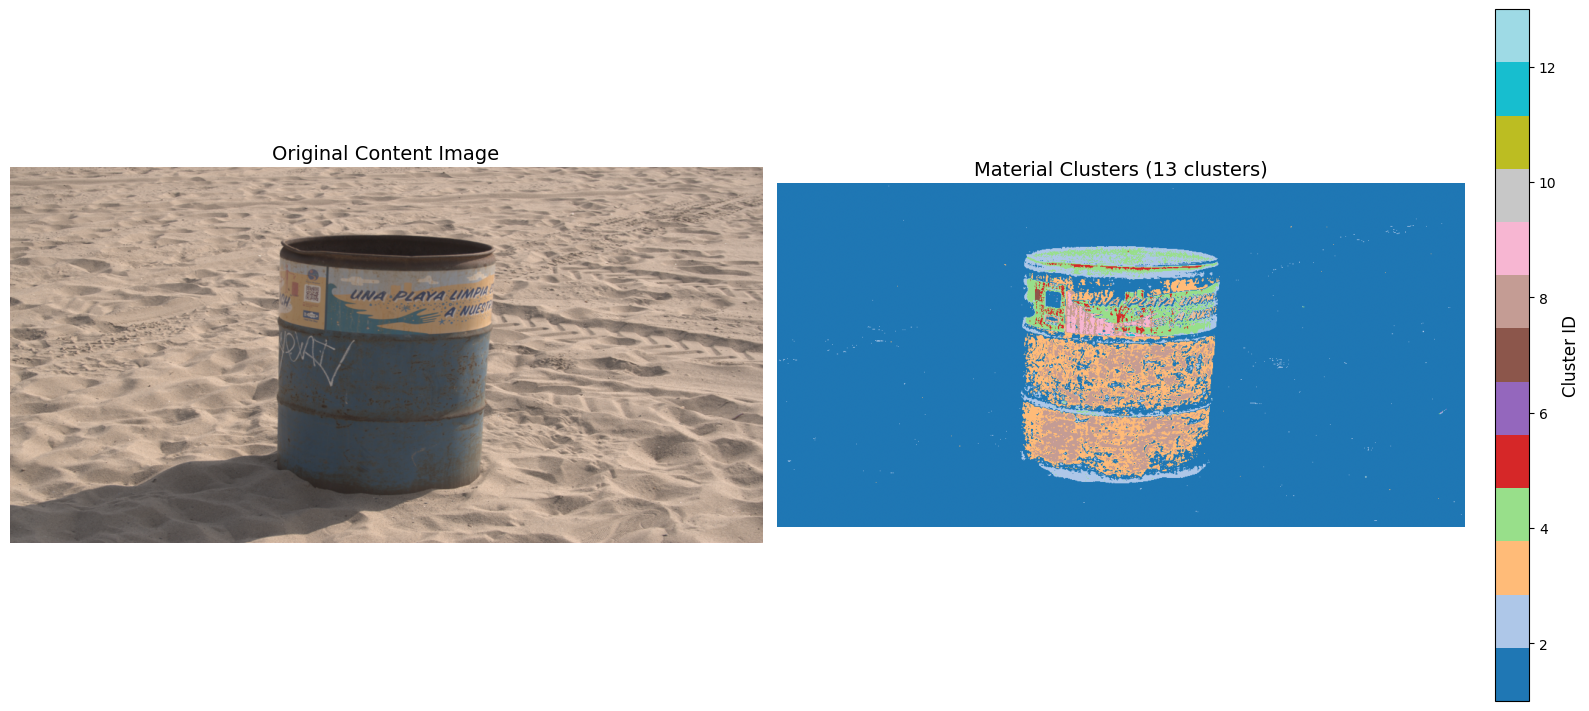

INFO: Estimated illumination vector norm 4.74545051967773


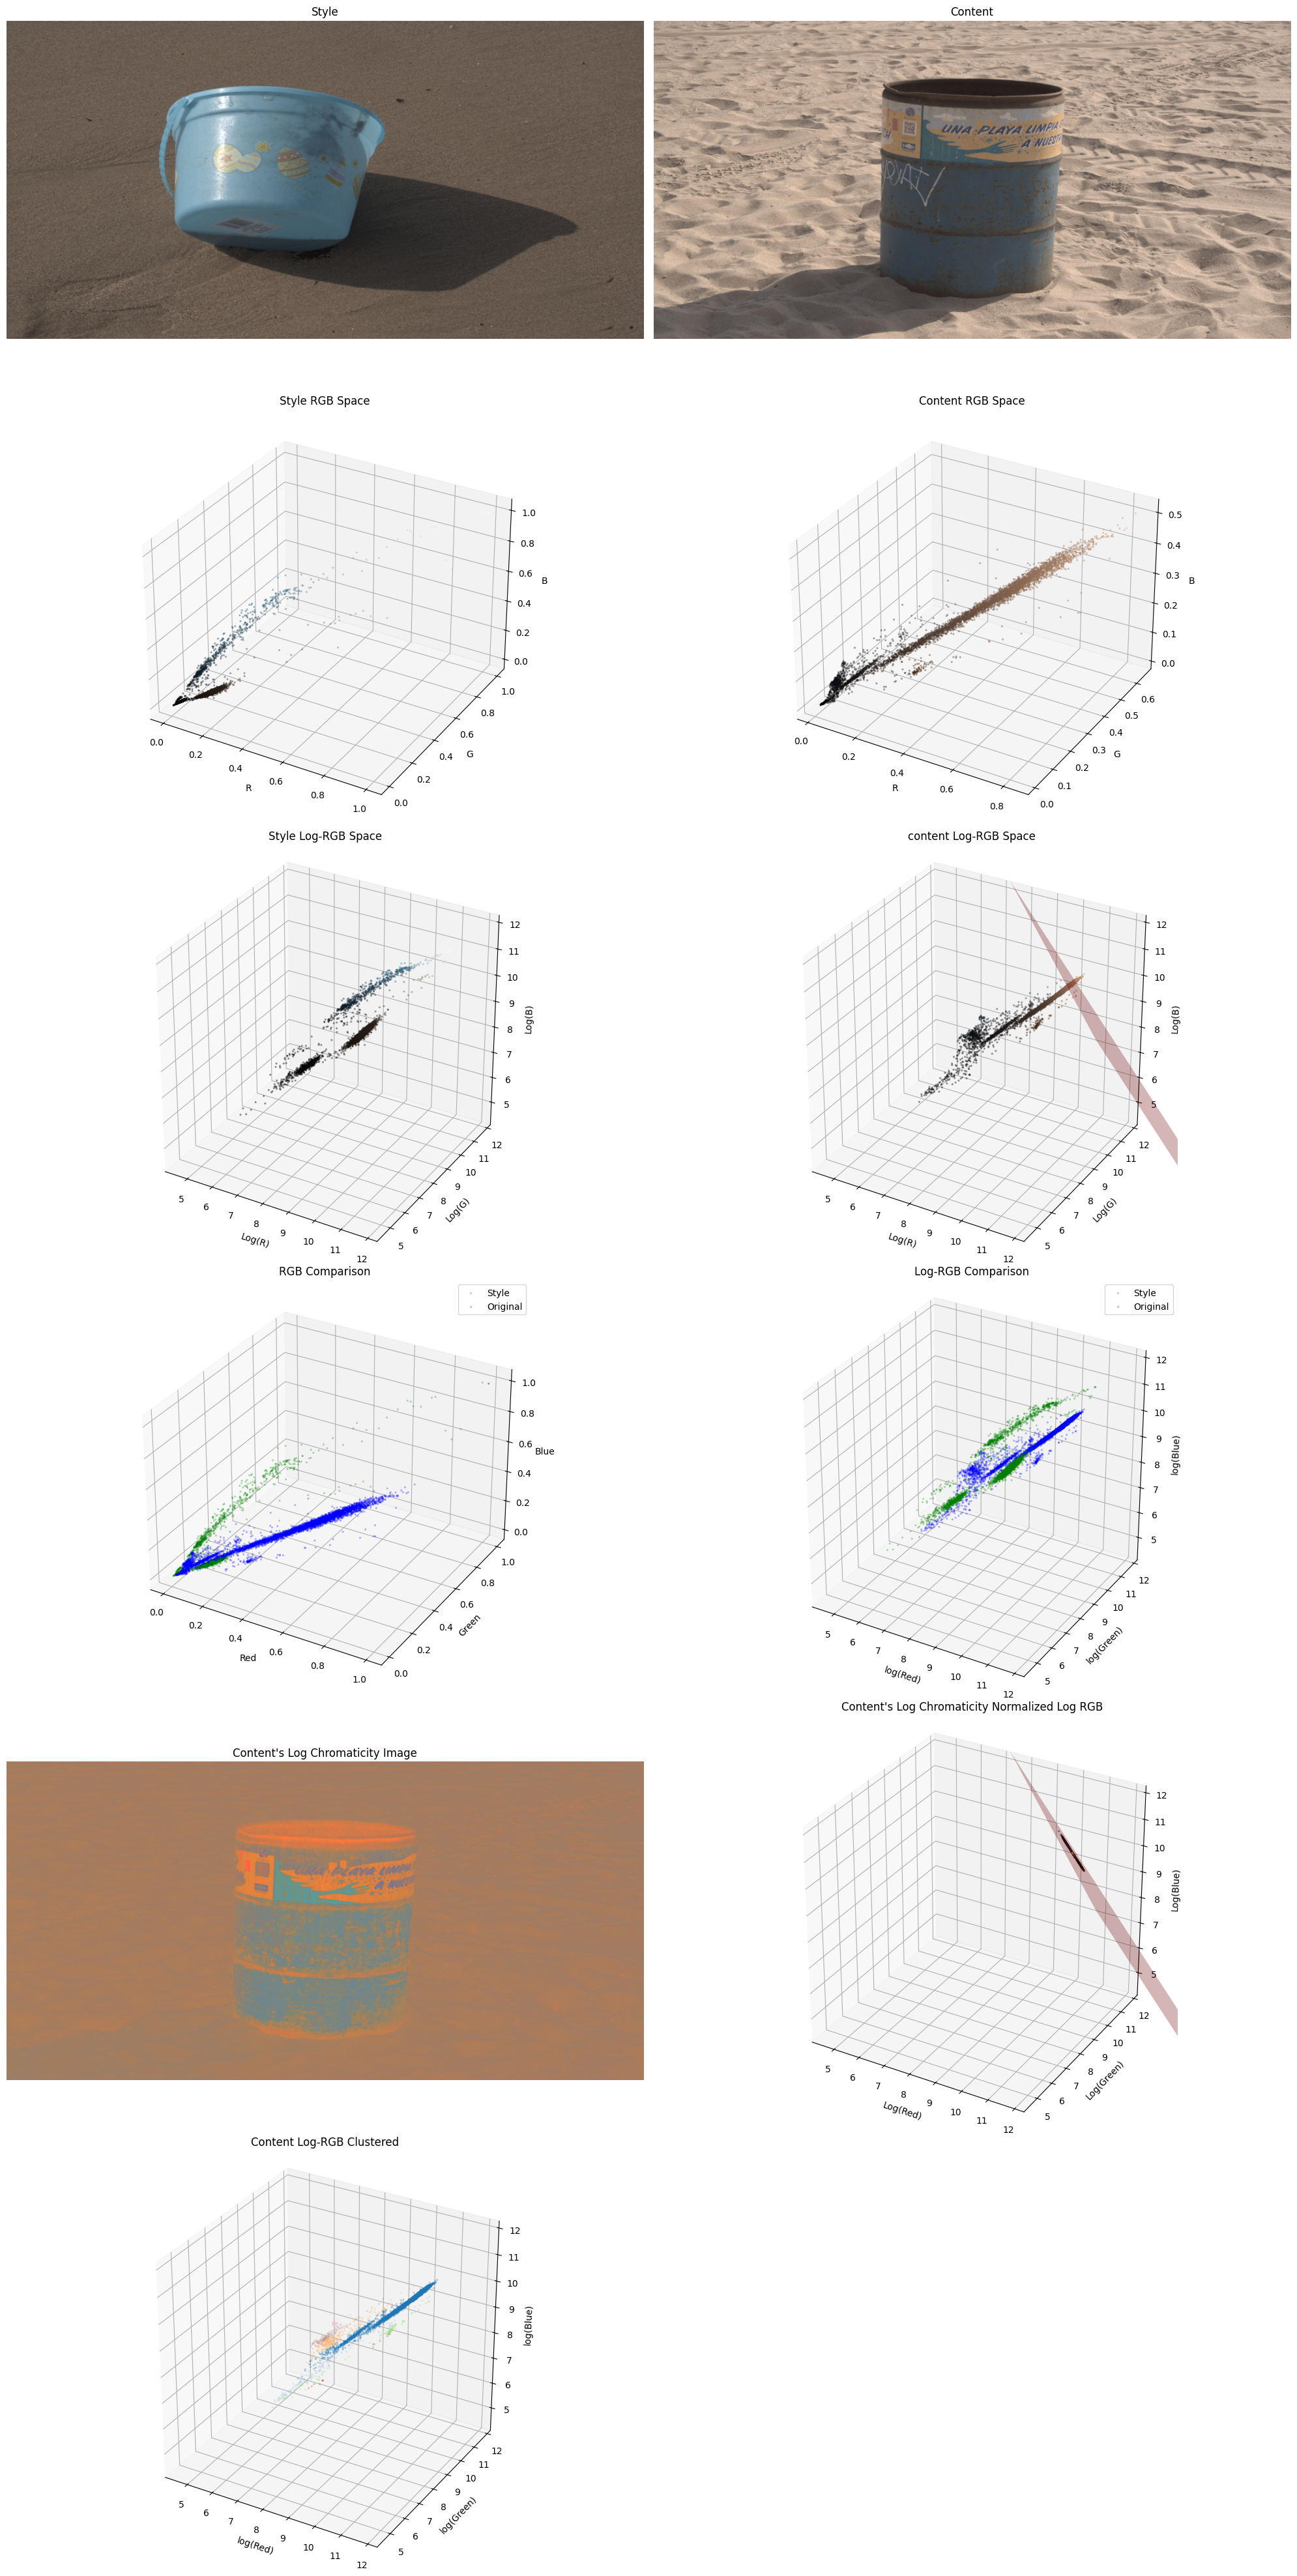

In [5]:
log_chroma_content, log_imgs, isd_maps, imgs, bin_masks = relight_content_image(
    # content_path="../data/compressed/bottle_sun.tiff",
    # style_path="../data/compressed/bottle_cloudy.tiff",
    content_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 000212.tiff",
    style_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 000225.tiff",
    isd_model="unet",  # mock, vit, unet
    isd_model_path="../weights/unet.pth",
    output_path="../data/target.png",
    shading_only=True,
    compression_factor=0.5,
    view_isd=False,  # see log rgb perpendicular to isd. should look similar to log chroma plane from max.
    clustering_method="greedy",  # greedy, kmeans
    # n_clusters=20,
    bin_radius=0.2,
)

Testing by copying over the same code block

(array([126385.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,      0.,      0.,      0.,   7814.]),
 array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,
         0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ]),
 <BarContainer object of 20 artists>)

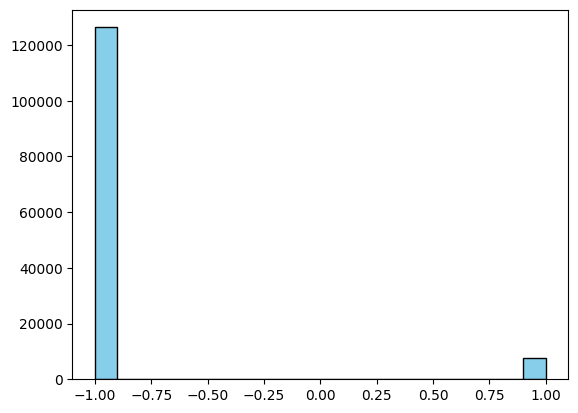

In [83]:
# Compute signed dist along isd for each pixel.
diff_vec = log_imgs[CONTENT] - log_chroma_content
signed_dist_map = (diff_vec * isd_maps[CONTENT]).sum(axis=2)  # dot product into (H,W)


# Tests
b = cosine_similarity(diff_vec.reshape(-1, 3), isd_maps[CONTENT].reshape(-1, 3))
plt.hist(b, bins=20, range=(-1, 1), color="skyblue", edgecolor="black")

Cluster 0 bin mask


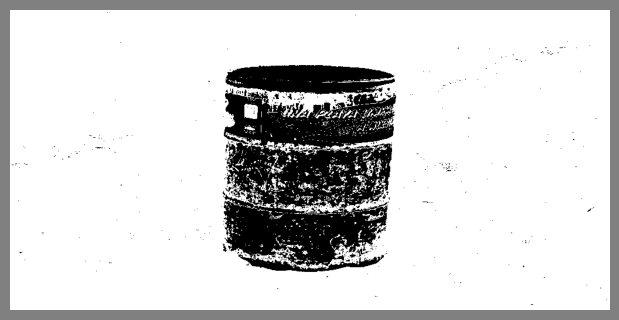

Cluster 1 bin mask


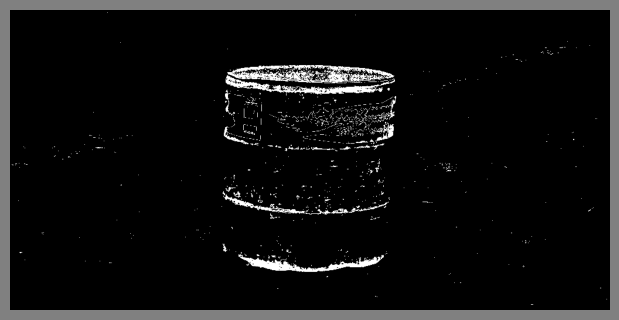

Cluster 2 bin mask


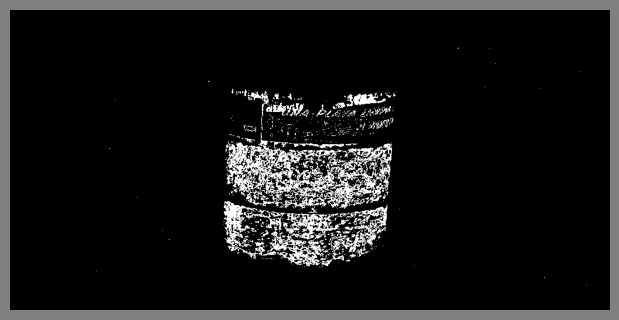

Cluster 3 bin mask


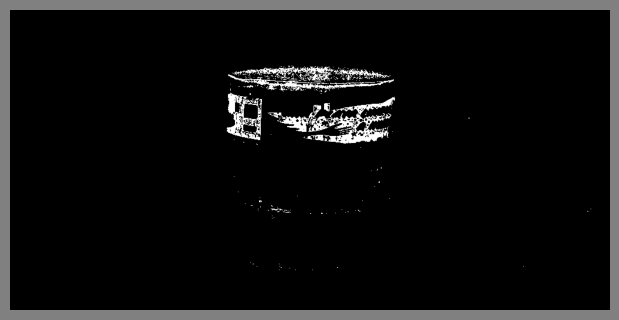

Cluster 4 bin mask


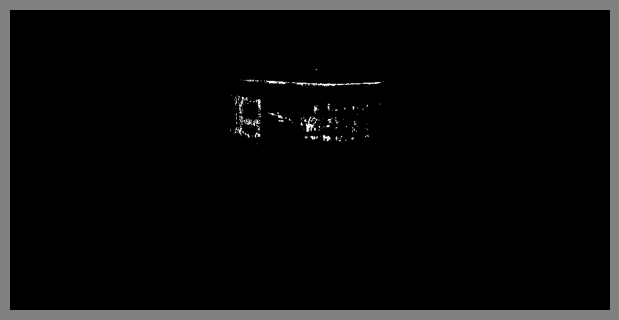

Cluster 5 bin mask


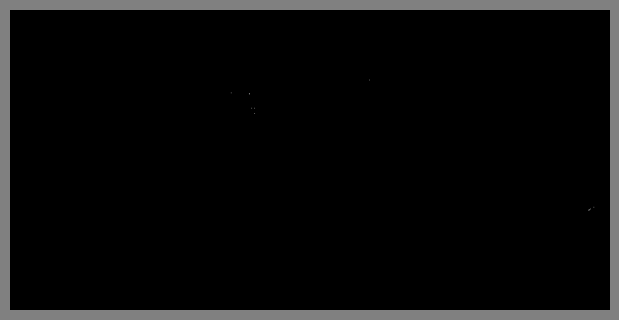

Cluster 6 bin mask


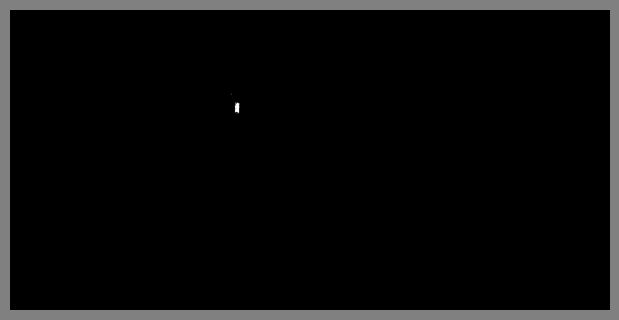

In [84]:
# Testing the bin masks (should agree with the clustering image given by max)
for i, bin_mask in enumerate(bin_masks[0:7]):
    print(f"Cluster {i} bin mask")
    plot_bin_masks(bin_mask)

Cluster 0 Debug:
Number of pxs belonging to the cluster: 451006
5th percentile: -3.092772904742442, 95th percentile: 0.03931305664806004,  length(diff): 3.132085961390502
Cluster 1 Debug:
Number of pxs belonging to the cluster: 13881
5th percentile: -6.033265126098185, 95th percentile: -1.2280284009923044,  length(diff): 4.805236725105881
Cluster 2 Debug:
Number of pxs belonging to the cluster: 28421
5th percentile: -4.08957509067849, 95th percentile: -1.4574446734588236,  length(diff): 2.632130417219666
Cluster 3 Debug:
Number of pxs belonging to the cluster: 10884
5th percentile: -6.110773207172314, 95th percentile: -1.1155621338273345,  length(diff): 4.995211073344979
Cluster 4 Debug:
Number of pxs belonging to the cluster: 1804
5th percentile: -4.912705964600823, 95th percentile: -1.8067338644446302,  length(diff): 3.105972100156193
Cluster 5 Debug:
Number of pxs belonging to the cluster: 12
5th percentile: -3.802153747960481, 95th percentile: -2.170333798214298,  length(diff): 1.6

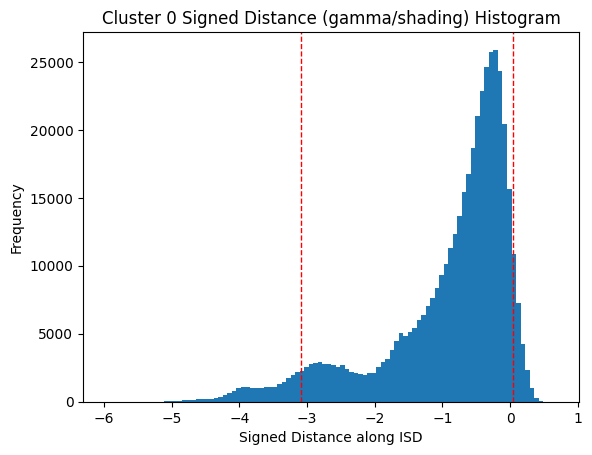

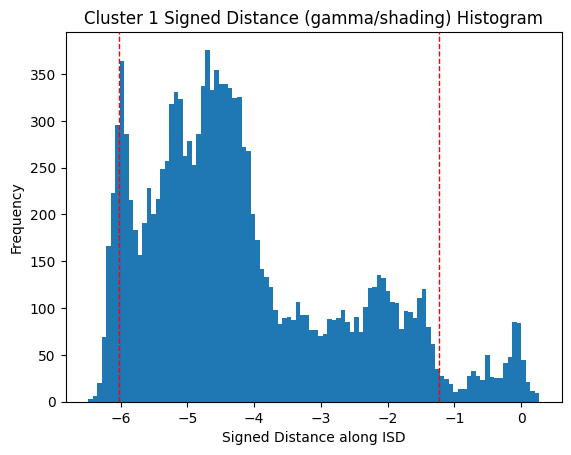

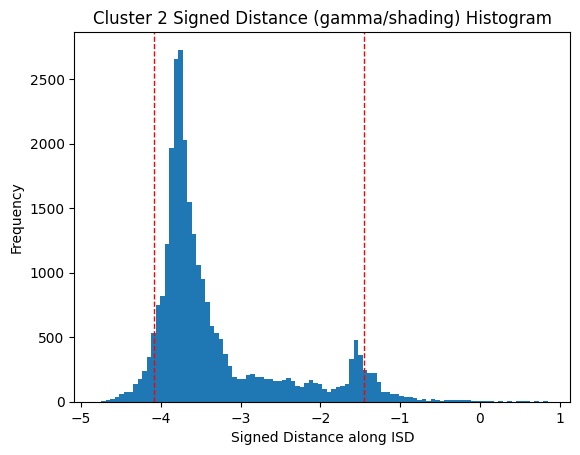

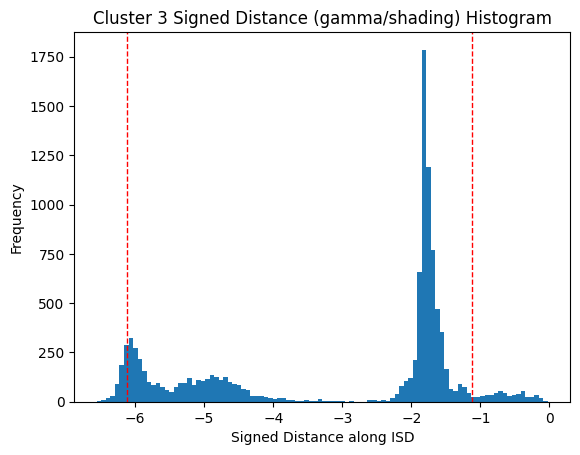

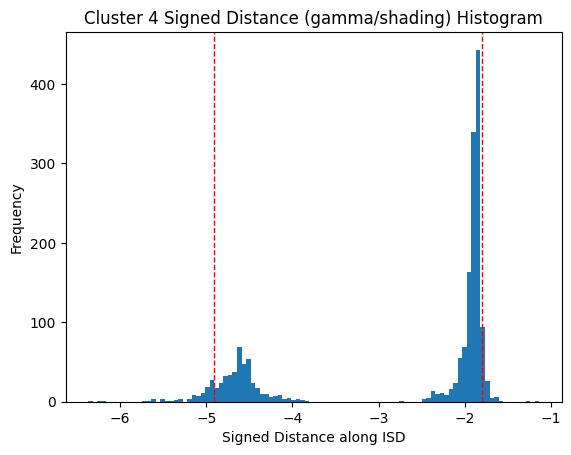

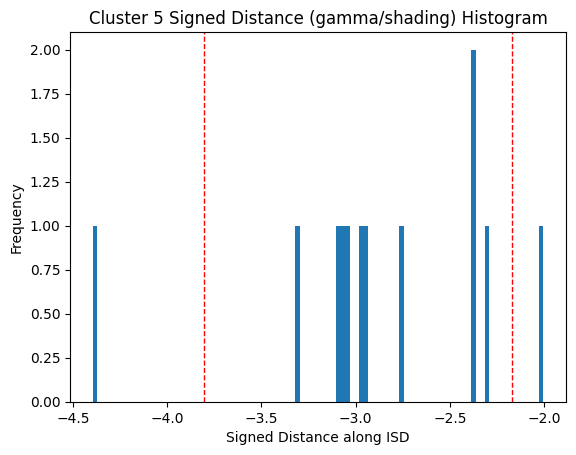

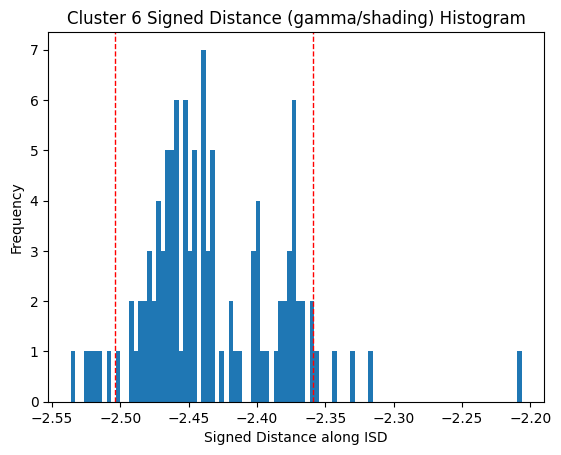

In [85]:
# Get the 5th and 95th percentile of signed dist distribution for each bin of pixels.
lengths = []
for i, bin_mask in enumerate(bin_masks):
    signed_dists = signed_dist_map[bin_mask].ravel()

    p5 = np.percentile(signed_dists, 5)
    p95 = np.percentile(signed_dists, 95)

    length = p95 - p5
    lengths.append(length)

    # Test: signed dist should have less samples, and show distribution for each bin
    if i < 7:
        print(f"Cluster {i} Debug:")
        print(f"Number of pxs belonging to the cluster: {signed_dists.shape[0]}")
        print(f"5th percentile: {p5}, 95th percentile: {p95},  length(diff): {length}")
        plt.figure()
        plt.hist(signed_dists, bins=100, label=i)
        plt.title(f"Cluster {i} Signed Distance (gamma/shading) Histogram")
        plt.xlabel("Signed Distance along ISD")
        plt.ylabel("Frequency")

        # add percentiles lines
        for p in [p5, p95]:
            plt.axvline(p, color="red", linestyle="--", linewidth=1)

plt.show()


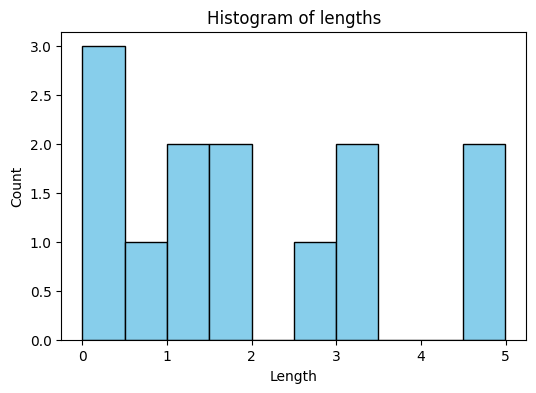

[0.         0.14494396 0.18894246 0.69488683 1.37505619 1.4321771
 1.63181995 1.94055801 2.63213042 3.1059721  3.13208596 4.80523673
 4.99521107]


In [86]:
# Create a histogram from this length array
bin_counts, bin_edges = np.histogram(np.array(lengths), bins=10)
bin_x = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # Use center as their position


# Test Plot
plt.figure(figsize=(6, 4))
plt.bar(
    bin_x,
    bin_counts,
    width=(bin_edges[1] - bin_edges[0]),
    color="skyblue",
    edgecolor="black",
)
plt.xlabel("Length")
plt.ylabel("Count")
plt.title("Histogram of lengths")
plt.show()

print(np.sort(np.array(lengths)))

In [87]:
# Extract peaks/modes from this histogram.
# Modes are defined as those histogram bins with relatively high counts.
# The count threshold is dynamically set to 30% of max count.
count_threshold = 0.3 * bin_counts.max()
mode_counts = bin_counts[bin_counts > count_threshold]
mode_x = bin_x[bin_counts > count_threshold]

# Use the rightmost mode as the illum vector norm.
illum_vector_norm = mode_x[-1]


# Test:
print(f"Count threshold: {count_threshold}")
print(f"Peak length: {mode_x}")
print(f"Peak counts: {mode_counts}")
print(f"Rightmost peak: {illum_vector_norm}")

Count threshold: 0.8999999999999999
Peak length: [0.24976055 0.74928166 1.24880277 1.74832388 2.74736609 3.2468872
 4.74545052]
Peak counts: [3 1 2 2 1 2 2]
Rightmost peak: 4.74545051967773
